# Lab 2
## Kinematics and Trajectory Planning for IRB140

## Steps

### 0. Import the necessary libraries

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import roboticstoolbox as rtb
import spatialmath.base as sb
from math import pi

### 1. Import robot model (ABB IRB140)

In [51]:
robot = rtb.models.DH.IRB140()
print(robot)

DHRobot: IRB 140 (by ABB), 6 joints (RRRRRR), dynamics, geometry, standard DH parameters
┌─────┬───────┬──────┬────────┬─────────┬────────┐
│ θⱼ  │  dⱼ   │  aⱼ  │   ⍺ⱼ   │   q⁻    │   q⁺   │
├─────┼───────┼──────┼────────┼─────────┼────────┤
│  q1 │ 0.352 │ 0.07 │ -90.0° │ -180.0° │ 180.0° │
│  q2 │     0 │ 0.36 │   0.0° │ -100.0° │ 100.0° │
│  q3 │     0 │    0 │ -90.0° │ -220.0° │  60.0° │
│  q4 │  0.38 │    0 │  90.0° │ -200.0° │ 200.0° │
│  q5 │     0 │    0 │ -90.0° │ -120.0° │ 120.0° │
│  q6 │ 0.065 │    0 │   0.0° │ -400.0° │ 400.0° │
└─────┴───────┴──────┴────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬─────┬──────┬───────┬─────┬──────┬──────┐
│ name │ q0  │ q1   │ q2    │ q3  │ q4   │ q5   │
├──────┼─────┼──────┼───────┼─────┼──────┼──────┤
│   qr │  0° │ -90° │  90°  │  0° │  90° │ -90° │
│   qz │  0° │  0°  │  0°   │  0° │  0°  │  0°  │
│   qd │  0° │ -90° │  180° │  0° │  0°  │ -90° │
└──────┴─────┴──────┴───────┴─────┴──────┴──────┘



### 2. Fill in the parameters of the robot model (ABB IRB140)

In [52]:
# Masses
robot.links[0].m = 12.0
robot.links[1].m = 35.0
robot.links[2].m = 25.0
robot.links[3].m = 18.0
robot.links[4].m = 6.5
robot.links[5].m = 1.5

In [53]:
# Centers of mass
robot.links[1].r = [ 0.6491, -1.3089,  0.2913]
robot.links[2].r = [ -0.0973, -1.6171,  0.9243]
robot.links[3].r = [ -0.0089,   -0.0867, -1.3649]
robot.links[4].r = [-0.4077,    0.00,   0.00]
robot.links[5].r = [ -0.000602, -0.004162, -0.486737]

In [54]:
# Inertia tensors
robot.links[1].I = [0.765, 0.31, 0.78, -0.3,   -0.14, 0.067]
robot.links[2].I = [1.38,  0.364, 1.09, 0.045, -0.31, -0.02]
robot.links[3].I = [0.349, 0.338, 0.014, 0.0,    0.021, 0.002]
robot.links[4].I = [0.005, 0.011, 0.016, 0.0,    0.0,   0.0]
robot.links[5].I = [0.005, 0.005, 0.0006, 0.0,   4e-5,  0.0]

In [55]:
# Motor inertias
robot.links[0].Jm = 0.0004
robot.links[1].Jm = 0.0004
robot.links[2].Jm = 0.0004
robot.links[3].Jm = 0.0004
robot.links[4].Jm = 0.0004
robot.links[5].Jm = 0.0004

In [56]:
# Viscous friction coefficients
robot.links[0].B = 0.0015
robot.links[1].B = 0.000817
robot.links[2].B = 0.00138
robot.links[3].B = 0.0000712
robot.links[4].B = 0.0000826
robot.links[5].B = 0.0000367

In [57]:
# Coulomb friction
robot.links[0].Tc = [0.395, -0.435]
robot.links[1].Tc = [0.126, -0.071]
robot.links[2].Tc = [0.132, -0.105]
robot.links[3].Tc = [0.0112, -0.0169]
robot.links[4].Tc = [0.00926, -0.0145]
robot.links[5].Tc = [0.00396, -0.0105]

In [58]:
# Joint limits
robot.links[0].qlim = [-np.pi, np.pi]
robot.links[1].qlim = [-1.5708, 1.9199]
robot.links[2].qlim = [-4.0143, 0.8727]
robot.links[3].qlim = [-3.4907, 3.4907]
robot.links[4].qlim = [-2.0071, 2.0071]
robot.links[5].qlim = [-6.9813, 6.9813]

### 3. Set the initial position and FK of the robot

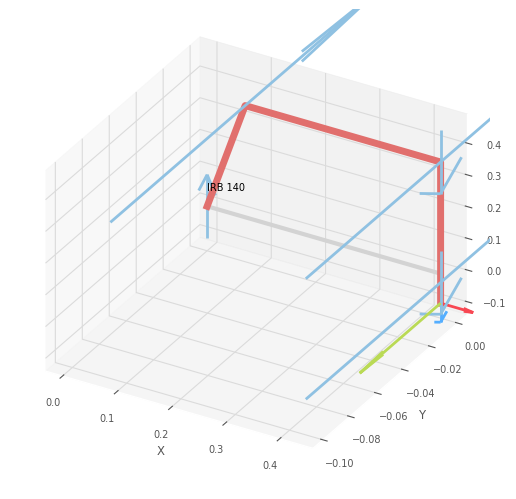

<Figure size 640x480 with 0 Axes>

In [59]:
# Set an arbitrary initial configuration
q_start = [0, 0, 0, 0, 0, 0]
robot.plot(q_start)
plt.show()

In [60]:
# Solve Forward Kinematics
T_start = robot.fkine(q_start)
print(T_start)

   1         0         0         0.43      
   0        -1         0         0         
   0         0        -1        -0.093     
   0         0         0         1         



### 4. Construct the Workspace 

In [61]:
n = 15                              # Number of samples per joint
joints_to_vary = [0, 1, 2, 3]       # Indices of joints to vary
fixed_joints = [0, 0, 0, 0, 0, 0]   # Fixed values for all joints

# Generate joint ranges
ranges = [np.linspace(robot.links[j].qlim[0], robot.links[j].qlim[1], n) for j in joints_to_vary]

# Preallocate array
total_points = n ** len(joints_to_vary)
pose = np.zeros((3, total_points))

idx = 0
# Nested loops of variable depth using product
from itertools import product

for values in product(*ranges):
    q = fixed_joints.copy()
    for j, val in zip(joints_to_vary, values):
        q[j] = val
    T = robot.fkine(q)
    pose[:, idx] = T.t
    idx += 1

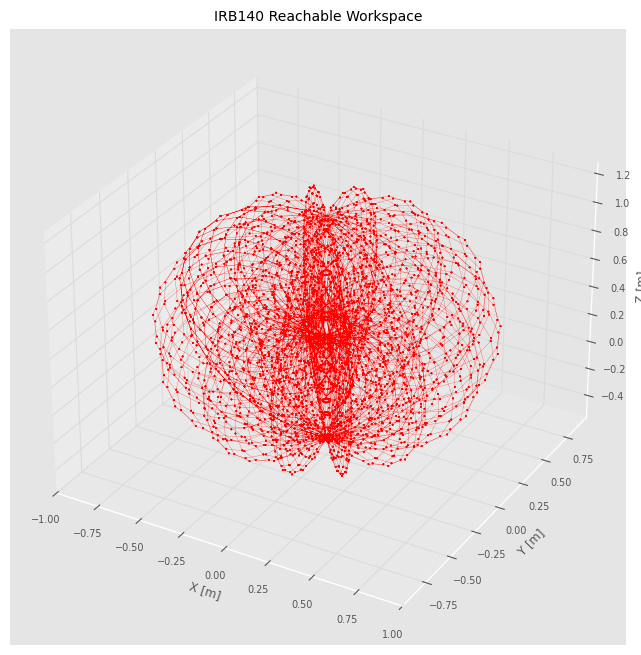

In [62]:
# Plot workspace
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection="3d")
ax.plot3D(pose[0], pose[1], pose[2], color='red', linewidth=0.15)
ax.scatter3D(pose[0], pose[1], pose[2], s=0.5, color='red', alpha=0.3)
ax.set_title("IRB140 Reachable Workspace")
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]"); ax.set_zlabel("Z [m]")
plt.show()

### 5. Inverse Kinematics (IK)

In [63]:
# Select end point and solve inverse kinematics
point = [0.4, 0.2, 0.3]
T_end = sb.transl(point)

Target Point: [0.4, 0.2, 0.3]
IK Joint Solution: [-2.67794504e+00 -2.56550085e+00 -3.11527785e+00 -4.86212670e-09
  2.53918604e+00 -4.63647615e-01]


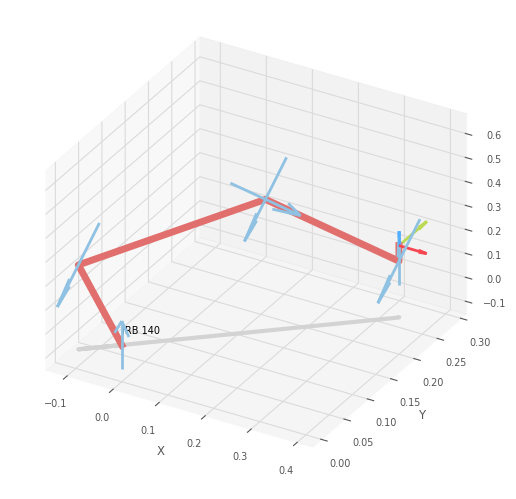

<Figure size 640x480 with 0 Axes>

In [64]:
sol = robot.ikine_GN(T_end)
q_end = sol.q

print(f"Target Point: {point}")
print(f"IK Joint Solution: {q_end}")
robot.plot(q_end)
plt.show()

### 6. Plan the trajectory 

In [65]:
# Plan the trajectory using three methods
N = 100
t_start = 0
t_stop = 5
time = np.linspace(t_start, t_stop, N)

# Method 1: Quintic polynomial (Joint space)
tr_jtraj = rtb.jtraj(q_start, q_end, time)

# Method 2: Trapezoidal Velocity Profile (LSPB)
tr_trap = rtb.mtraj(rtb.trapezoidal, q_start, q_end, time)

# Method 3: Quintic Polynomial (via mtraj)
tr_quin = rtb.mtraj(rtb.quintic, q_start, q_end, time)

### 7. Position Plots

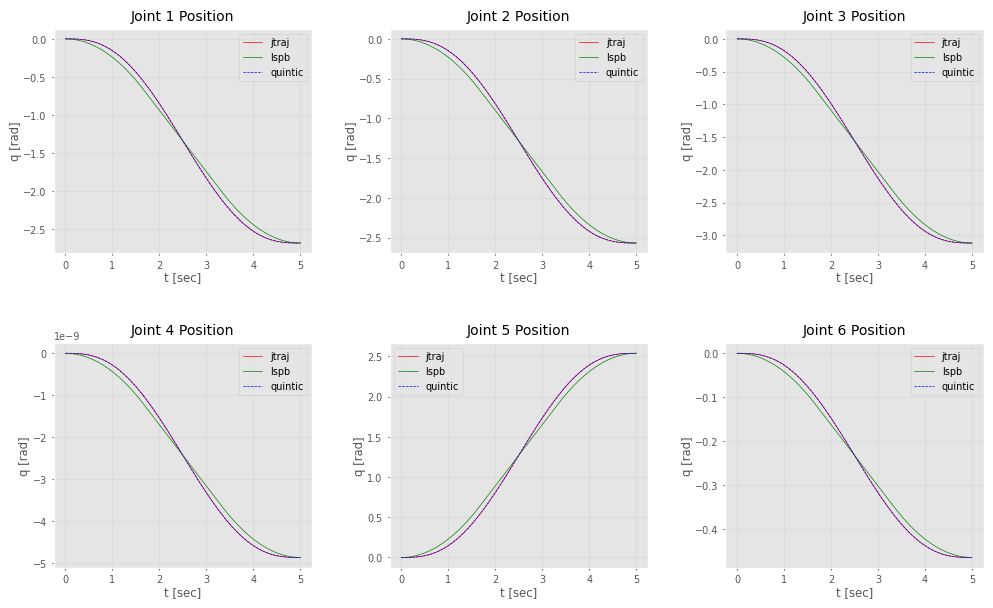

In [66]:
plt.figure(figsize=(12, 7), dpi=100)
for g in range(1, 7):
    plt.subplot(2, 3, g)
    plt.subplots_adjust(wspace=0.3, hspace=0.4)
    plt.plot(time, tr_jtraj.q[:, g-1], 'r-', label="jtraj")
    plt.plot(time, tr_trap.q[:, g-1], 'g-', label="lspb")
    plt.plot(time, tr_quin.q[:, g-1], 'b--', label="quintic")
    plt.title(f"Joint {g} Position")
    plt.ylabel("q [rad]")
    plt.xlabel("t [sec]")
    plt.grid(True)
    plt.legend()
plt.show()

### 8. Velocity Plots

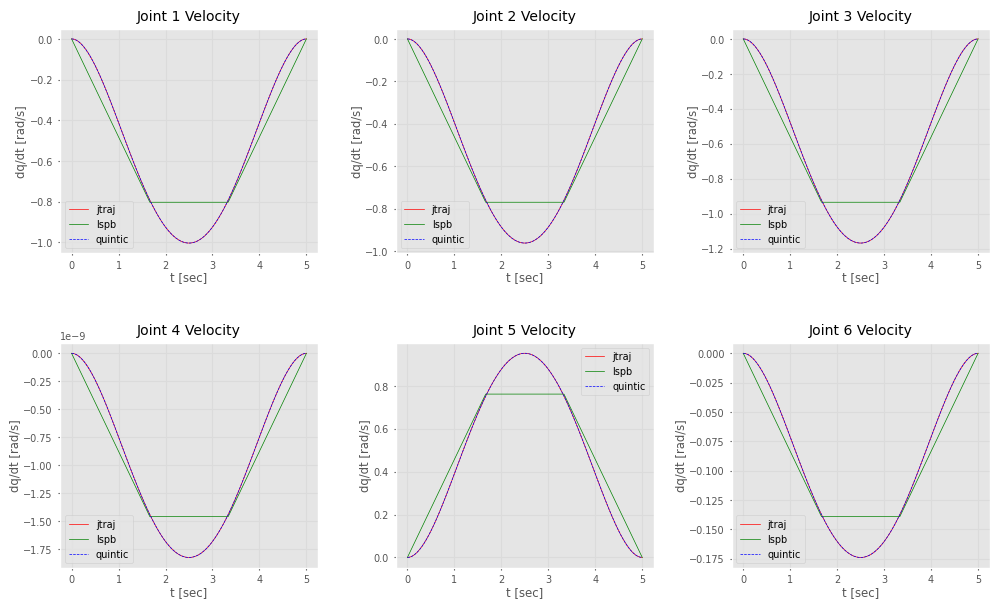

In [67]:
plt.figure(figsize=(12, 7), dpi=100)
for g in range(1, 7):
    plt.subplot(2, 3, g)
    plt.subplots_adjust(wspace=0.3, hspace=0.4)
    plt.plot(time, tr_jtraj.qd[:, g-1], 'r-', label="jtraj")
    plt.plot(time, tr_trap.qd[:, g-1], 'g-', label="lspb")
    plt.plot(time, tr_quin.qd[:, g-1], 'b--', label="quintic")
    plt.title(f"Joint {g} Velocity")
    plt.ylabel("dq/dt [rad/s]")
    plt.xlabel("t [sec]")
    plt.grid(True)
    plt.legend()
plt.show()

### 9. Acceleration Plots

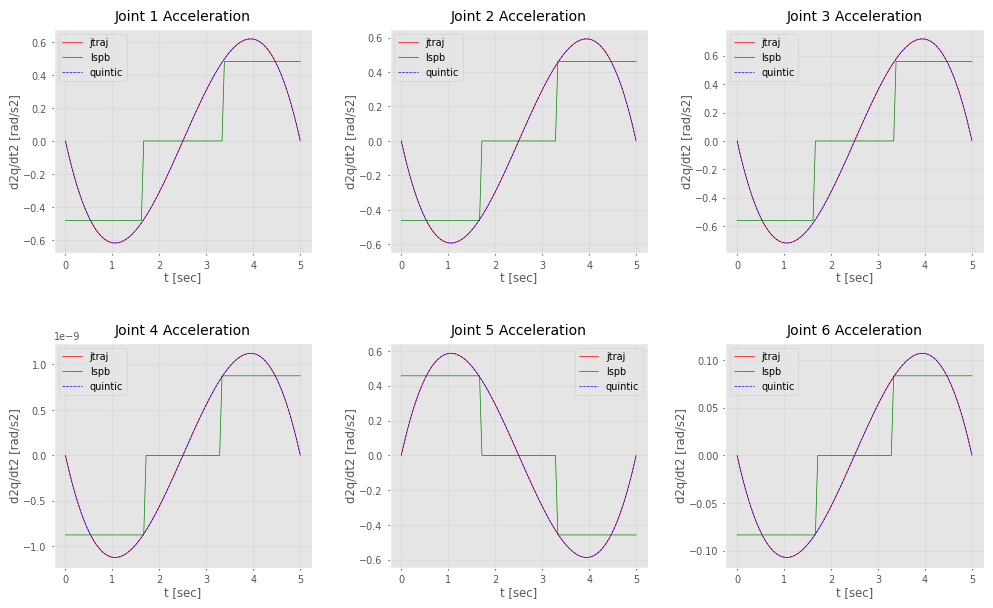

In [68]:
plt.figure(figsize=(12, 7), dpi=100)
for g in range(1, 7):
    plt.subplot(2, 3, g)
    plt.subplots_adjust(wspace=0.3, hspace=0.4)
    plt.plot(time, tr_jtraj.qdd[:, g-1], 'r-', label="jtraj")
    plt.plot(time, tr_trap.qdd[:, g-1], 'g-', label="lspb")
    plt.plot(time, tr_quin.qdd[:, g-1], 'b--', label="quintic")
    plt.title(f"Joint {g} Acceleration")
    plt.ylabel("d2q/dt2 [rad/s2]")
    plt.xlabel("t [sec]")
    plt.grid(True)
    plt.legend()
plt.show()

### 10. Conclusions

### 1. Kinematic Modeling
* **Forward Kinematics (FK):** The mathematical model derived from the DH parameters successfully maps the joint coordinates to the Cartesian workspace. By applying the dynamic and kinematic parameters from Lab #1, we ensured that the digital twin accurately represents the physical limits and behavior of the IRB140.
* **Inverse Kinematics (IK):** The iterative numerical method (Levenberg-Marquardt) proved to be highly effective for this 6-DOF robot. It successfully translated a desired tool position into the required joint angles, confirming that the target point chosen was within the operational boundaries.

### 2. Workspace Visualization
* The construction of the workspace by sampling the first three joints revealed a **spherical shell geometry**. This visualization is crucial for industrial applications as it identifies the "dead zones" (areas the robot cannot reach) and the maximum reach limits, which are dictated by the `qlim` constraints defined in the DH parameters.

### 3. Trajectory Planning Comparison
Three different methods were analyzed to move the robot from the initial to the final configuration:

*   **Jtraj (Quintic Polynomial):** This method provided the smoothest transition. Since it uses a fifth-order polynomial, both velocity and acceleration are continuous, minimizing mechanical vibrations and stress on the motors.
*   **Trapezoidal (LSPB - Linear Segment with Parabolic Blends):** This method is characterized by a constant velocity phase. While efficient for tasks requiring steady motion, the acceleration plots showed sharp transitions (discontinuities in the derivative of acceleration), which in a real-world scenario could lead to high "jerk" and premature wear of the joints.
*   **Quintic (mtraj):** Similar to `jtraj`, it yielded smooth curves. The comparison shows that for high-precision industrial tasks, quintic profiles are superior to trapezoidal ones due to their superior smoothness at the start and end of the motion.

### 4. General Summary
The laboratory work demonstrates that effective robotic control requires not only an accurate kinematic model but also a careful selection of trajectory profiles. For the IRB140, while all three methods reached the target point in the same time ($t=5s$), the **Quintic/Jtraj** profiles are recommended for real-world implementation to preserve the lifespan of the robot's actuators and ensure high-precision tracking.